In [1]:
import pandas as pd
import numpy as np

In [2]:
dot_df_path = "/scratch1/smaruj/natural_dots/filtered_dots.tsv"
dot_df = pd.read_csv(dot_df_path, sep="\t")

In [12]:
patch_dir = "/scratch1/smaruj/natural_dots/dot_patches"

In [4]:
dot_df

,chrom,BIN1_START,BIN1_END,BIN2_START,BIN2_END,FDR,DETECTION_SCALE,window_start,window_end,anchor2_center_bin,anchors_dist,anchor1_center_bin
0,chr1,91970000,91980000,92450000,92460000,0.011590,2.111213,91536592,92847312,384,234,150
1,chr1,91970000,91980000,92610000,92620000,0.036990,2.599208,91696592,93007312,384,312,72
2,chr1,92160000,92170000,92450000,92460000,0.038089,2.111213,91536592,92847312,384,141,243
3,chr1,92490000,92500000,92610000,92620000,0.017336,3.200000,91696592,93007312,384,58,326
4,chr1,92680000,92690000,92850000,92860000,0.009500,4.222425,91936592,93247312,384,83,301
...,...,...,...,...,...,...,...,...,...,...,...,...
6813,chr19,36140000,36150000,36440000,36450000,0.013890,6.400000,35526592,36837312,384,146,238
6814,chr19,36180000,36190000,36430000,36440000,0.000199,2.111213,35516592,36827312,384,122,262
6815,chr19,37050000,37060000,37260000,37270000,0.030770,2.111213,36346592,37657312,384,102,282
6816,chr19,37550000,37560000,37930000,37940000,0.037086,2.599208,37016592,38327312,384,185,199


In [5]:
import matplotlib.pyplot as plt

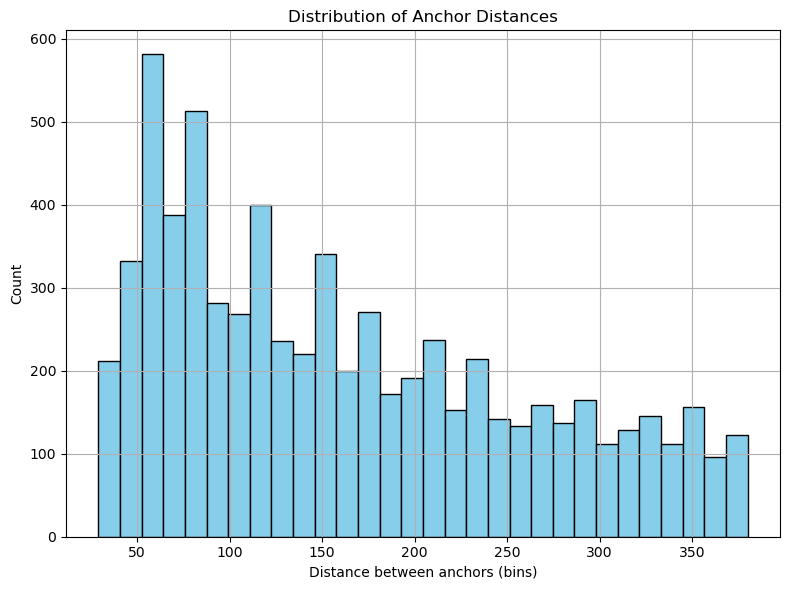

In [8]:
plt.figure(figsize=(8, 6))
plt.hist(dot_df["anchors_dist"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Distance between anchors (bins)")
plt.ylabel("Count")
plt.title("Distribution of Anchor Distances")
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
lower_bound = 0
upper_bound = 50

In [62]:
selected_df = dot_df[(dot_df["anchors_dist"] >= lower_bound) & (dot_df["anchors_dist"] <= upper_bound)]

In [11]:
import os

In [63]:
patches = []

for idx in selected_df.index:
    patch_path = os.path.join(patch_dir, f"patch_{idx}.npy")
    if os.path.exists(patch_path):
        patch = np.load(patch_path)
        if patch.shape == (15, 15):
            patches.append(patch)
        else:
            print(f"Skipping patch_{idx}.npy due to shape {patch.shape}")
    else:
        print(f"Missing patch file: patch_{idx}.npy")

In [64]:
if len(patches) > 0:
    pileup = np.nanmean(np.stack(patches, axis=0), axis=0)
    print(f"Pile-up created using {len(patches)} valid patches.")
else:
    raise ValueError("No valid patches found in the selected distance range.")

Pile-up created using 544 valid patches.


In [26]:
import seaborn as sns

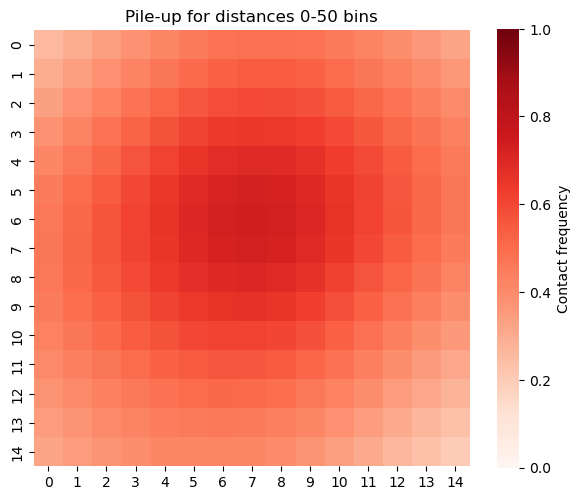

In [65]:
plt.figure(figsize=(6, 5))
sns.heatmap(pileup, cmap="Reds", center=np.nanmean(pileup), square=True, cbar_kws={"label": "Contact frequency"}, vmin=0.0, vmax=1.0)
plt.title(f"Pile-up for distances {lower_bound}-{upper_bound} bins")
plt.tight_layout()
plt.show()